In [1]:
#Importación de data
from glob import glob

In [2]:
file_list = glob('*.pkl')
file_list

['dataResume.pkl']

In [3]:
#Importamos la data
import pickle 
with open("dataResume.pkl", 'rb') as file:
    dataResume = pickle.load(file)


In [4]:
#Agentes Disponibles
list(dataResume.keys())

['CorrelationPunishment05DDPG Agent',
 'CorrelationPunishment07DDPG Agent',
 'RewardNetProfitDDPG Agent',
 'RMemorySize10DDPG Agent',
 'RMemorySize3DDPG Agent',
 'TotalDDPG Agent',
 'Random Agent',
 'SP500 Agent']

In [5]:
#Metricas Disponibles
dataResume['TotalDDPG Agent'].keys()

dict_keys(['net_worths_delta', 'pearson_correlations', 'rewards', 'portfolio_returns', 'stds', 'sharpe_ratios', 'net_worths', 'net_worths_delta_acum', 'rewards_acum'])

In [6]:
#Función para Graficar los puntos
import matplotlib.pyplot as plt
def plotScatterAandB(X , Y , finalResults, path_to_save = None, label_list_dict = None):
    fig, ax = plt.subplots()
    for expName in finalResults.keys():
        tag = expName
        if label_list_dict:
              tag = label_list_dict[expName]      
        ax.scatter(finalResults[expName][X], finalResults[expName][Y], label=tag)

    xForLabel = X.replace("_", " ").capitalize()
    yForLabel = Y.replace("_", " ").capitalize()
    if label_list_dict:
        ax.set_title(label_list_dict['title'], fontsize=14)
        ax.set_xlabel(label_list_dict['xlabel'], fontsize=14)
        ax.set_ylabel(label_list_dict['ylabel'], fontsize=14)
    else:
        ax.set_xlabel(xForLabel)
        ax.set_ylabel(yForLabel)
    ax.legend()
    if path_to_save:
        plt.savefig(path_to_save + 'plot_Scatter.png')
    plt.show()

In [7]:
#Hay que cambiar esto según se necesite
label_list_dict = {'CorrelationPunishment05DDPG Agent' : 'Correlation Punish 0.5 Agent',
                   'CorrelationPunishment07DDPG Agent' : 'Correlation Punish 0.7 Agent',
                   'TotalDDPG Agent' : 'Base Agent',
                   'RewardNetProfitDDPG Agent' : 'Just Return Agent',
                   'RMemorySize10DDPG Agent' : '10 Steps rolling Agent',
                   'RMemorySize3DDPG Agent' : '3 Steps rolling Agent',
                   'Random Agent' : 'Random Agent',
                   'SP500 Agent' : 'SP500 Agent',
                   'title': 'Pearson Correlation vs Cumulative Net Worth',
                   'xlabel': 'Pearson Correlation',
                   'ylabel': 'Cumulative Net Worth',}

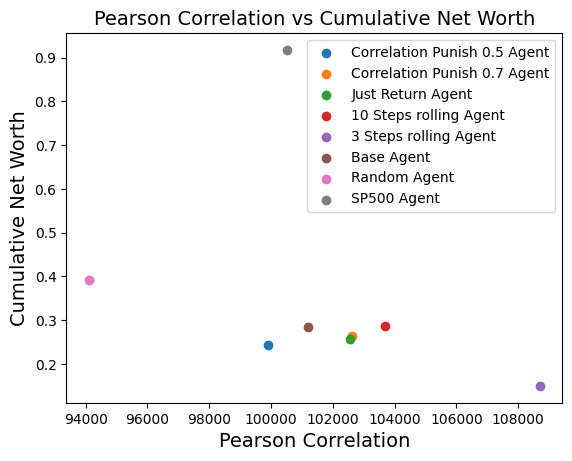

In [8]:
# Para el Gráfico A de la figura 4.7 , Acá se rompe un poco el gráfico 
# porque el SP 500 tiene mucha correlación con el indice de mercado 
# (no es 1 por la limitación de comprar acciones enteras con un volumen de dinero mucho más pequeño, pero si muy alta)
plotScatterAandB(X='net_worths_delta_acum', Y='pearson_correlations', finalResults=dataResume, label_list_dict = label_list_dict,  path_to_save = None)

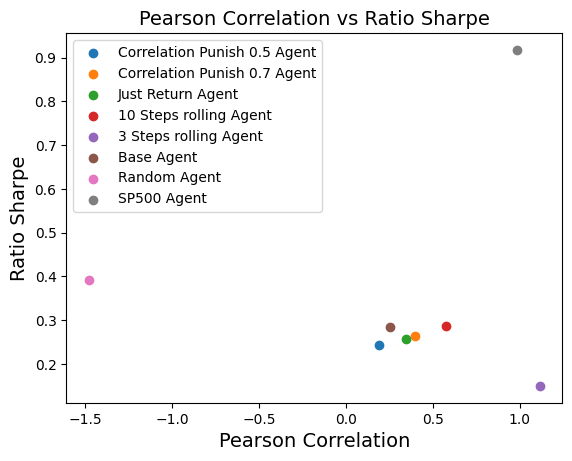

In [9]:
#Para el Gráfico A de la figura 4.8


label_list_dict = {'CorrelationPunishment05DDPG Agent' : 'Correlation Punish 0.5 Agent',
                   'CorrelationPunishment07DDPG Agent' : 'Correlation Punish 0.7 Agent',
                   'TotalDDPG Agent' : 'Base Agent',
                   'RewardNetProfitDDPG Agent' : 'Just Return Agent',
                   'RMemorySize10DDPG Agent' : '10 Steps rolling Agent',
                   'RMemorySize3DDPG Agent' : '3 Steps rolling Agent',
                   'Random Agent' : 'Random Agent',
                   'SP500 Agent' : 'SP500 Agent',
                   'title': 'Pearson Correlation vs Ratio Sharpe',
                   'xlabel': 'Pearson Correlation',
                   'ylabel': 'Ratio Sharpe',}

plotScatterAandB(X='sharpe_ratios', Y='pearson_correlations', finalResults=dataResume, label_list_dict = label_list_dict,  path_to_save = None)